In [3]:
# Import required libraries

import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the Dataset
df = pl.read_csv("../data/raw/maternal_health_dataset.csv")

In [5]:
# Display the first five rows

df.head()

id,age_years,gravidity,parity,gestational_age_weeks,bmi_pre_pregnancy,systolic_bp_mmhg,diastolic_bp_mmhg,hemoglobin_gdl,anemia_status,fasting_glucose_mgdl,proteinuria,hiv_status,anc_visits,delivery_mode,primary_complication,pregnancy_outcome,risk_level
i64,i64,i64,i64,f64,f64,i64,i64,f64,str,i64,i64,i64,i64,str,str,str,str
1,23,3,2,33.7,24.7,121,80,10.9,"""mild""",75,0,0,6,"""vaginal""","""none""","""live_birth""","""low"""
2,28,5,4,31.0,15.4,103,68,10.5,"""mild""",74,0,0,4,"""vaginal""","""none""","""live_birth""","""low"""
3,20,3,1,24.5,29.9,117,65,12.5,"""none""",85,0,1,5,"""vaginal""","""none""","""live_birth""","""high"""
4,31,2,1,33.5,23.0,131,99,12.9,"""none""",87,2,0,4,"""vaginal""","""preeclampsia""","""live_birth""","""moderate"""
5,32,9,8,22.3,25.4,159,90,12.3,"""none""",77,4,0,4,"""vaginal""","""preeclampsia""","""live_birth""","""moderate"""


### Observation

The dataset loaded successfully.

The first five rows show that each record represents one pregnancy with demographic, clinical and pregnancy-related variables together with the target variable (risk_level).

In [6]:
# Display dataset dimensions

print(f"Rows: {df.height}")
print(f"Columns: {df.width}")

Rows: 30000
Columns: 18


### Observation

The dataset contains **30000** observations and **18** features.

This indicates that the dataset is sufficiently large for machine learning modelling.

In [7]:
# Display column names

df.columns

['id',
 'age_years',
 'gravidity',
 'parity',
 'gestational_age_weeks',
 'bmi_pre_pregnancy',
 'systolic_bp_mmhg',
 'diastolic_bp_mmhg',
 'hemoglobin_gdl',
 'anemia_status',
 'fasting_glucose_mgdl',
 'proteinuria',
 'hiv_status',
 'anc_visits',
 'delivery_mode',
 'primary_complication',
 'pregnancy_outcome',
 'risk_level']

### Observation

The dataset contains demographic, obstetric and clinical variables together with the target variable (risk_level).

In [8]:
# Display data types

df.dtypes

[Int64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Int64,
 Int64,
 Float64,
 String,
 Int64,
 Int64,
 Int64,
 Int64,
 String,
 String,
 String,
 String]

### Observation

The dataset contains both numerical and categorical variables.

These data types will guide preprocessing and feature engineering in later stages.

In [9]:
# Display descriptive statistics

df.describe()

statistic,id,age_years,gravidity,parity,gestational_age_weeks,bmi_pre_pregnancy,systolic_bp_mmhg,diastolic_bp_mmhg,hemoglobin_gdl,anemia_status,fasting_glucose_mgdl,proteinuria,hiv_status,anc_visits,delivery_mode,primary_complication,pregnancy_outcome,risk_level
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str,str,str,str
"""count""",30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,30000.0,"""30000""",30000.0,30000.0,30000.0,30000.0,"""30000""","""30000""","""30000""","""30000"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0"""
"""mean""",5000.5,26.049533,3.175,2.070533,27.357543,23.70632,116.223467,72.681967,10.329173,null,84.929933,0.407833,0.100967,3.896133,null,null,null,null
"""std""",2886.799445,5.521126,2.2361,2.211498,7.227483,4.289351,15.924999,11.02245,2.033087,null,12.085618,0.930126,0.30129,2.241275,null,null,null,null
"""min""",1.0,15.0,1.0,0.0,6.0,14.0,72.0,45.0,3.1,"""mild""",49.0,0.0,0.0,0.0,"""caesarean""","""eclampsia""","""live_birth""","""high"""
"""25%""",2501.0,22.0,1.0,0.0,22.3,20.6,106.0,66.0,8.8,null,77.0,0.0,0.0,2.0,null,null,null,null
"""50%""",5001.0,26.0,3.0,1.0,27.6,23.6,114.0,71.0,10.6,null,83.0,0.0,0.0,4.0,null,null,null,null
"""75%""",7500.0,30.0,4.0,3.0,32.7,26.6,122.0,77.0,11.9,null,90.0,0.0,0.0,5.0,null,null,null,null
"""max""",10000.0,47.0,16.0,15.0,42.0,39.8,208.0,133.0,15.8,"""severe""",165.0,4.0,1.0,15.0,"""vaginal""","""severe_anemia""","""stillbirth""","""moderate"""


### Observation

The descriptive statistics indicate that the dataset contains **30,000 complete maternal health records** with no missing values across any of the features.

The numerical variables have realistic ranges. For example, maternal age ranges from **15 to 47 years**, gestational age ranges from **6 to 42 weeks**, BMI ranges from **14.0 to 39.8 kg/m²**, systolic blood pressure ranges from **72 to 208 mmHg**, and fasting blood glucose ranges from **49 to 165 mg/dL**.

The summary statistics suggest that the dataset is of good quality and suitable for exploratory data analysis and machine learning. However, the `id` column appears to repeat across the merged datasets and will therefore be treated only as a record identifier rather than a predictive feature.

In [10]:
# Display unique risk categories

df["risk_level"].unique().sort()

risk_level
str
"""high"""
"""low"""
"""moderate"""


### Observation

The machine learning task is a multi-class classification problem because the target variable consists of multiple risk categories.

In [11]:
# Number of Records per Risk Category
(
    df.group_by("risk_level")
      .len()
      .sort("risk_level")
)

risk_level,len
str,u32
"""high""",7339
"""low""",12100
"""moderate""",10561


### Observation

The dataset contains three maternal health risk categories:

- **Low Risk:** 12,100 records
- **Moderate Risk:** 10,561 records
- **High Risk:** 7,339 records

Although the classes are not perfectly balanced, each category contains a substantial number of records. This provides the machine learning model with sufficient examples to learn the characteristics of each risk level while reducing the likelihood of severe class imbalance.

In [12]:
# Check duplicate rows

duplicate_count = df.height - df.unique().height

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


## Observation

- No duplicate row 

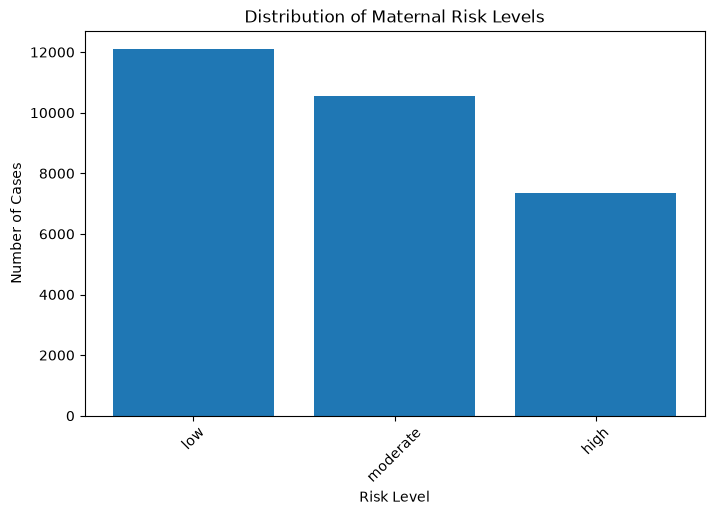

In [16]:
# Extract values from Polars DataFrame

risk_levels = risk_distribution["risk_level"].to_list()
risk_counts = risk_distribution["count"].to_list()


plt.figure(figsize=(8,5))

plt.bar(
    risk_levels,
    risk_counts
)

plt.title("Distribution of Maternal Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)

plt.show()

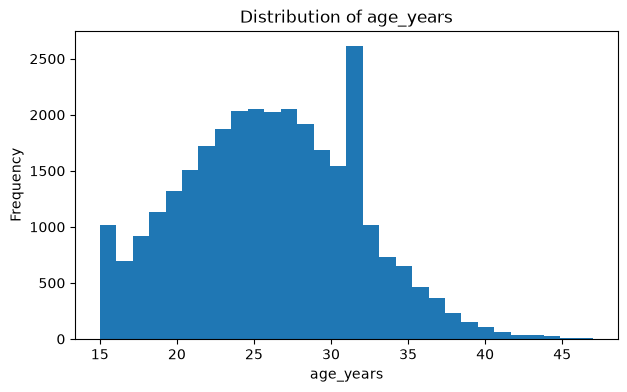

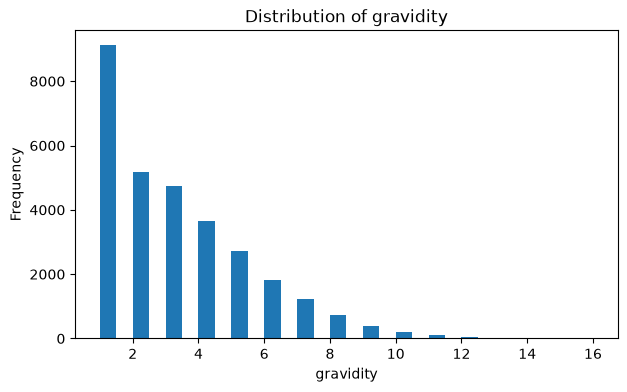

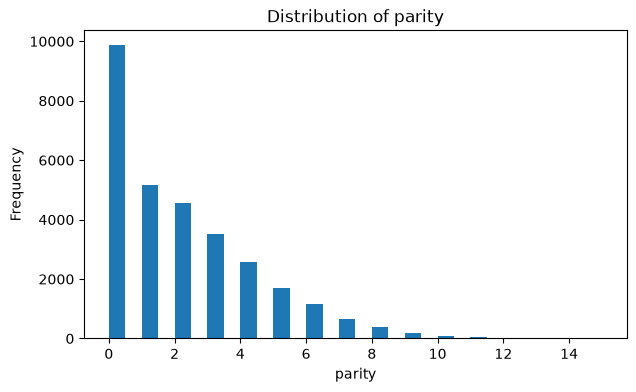

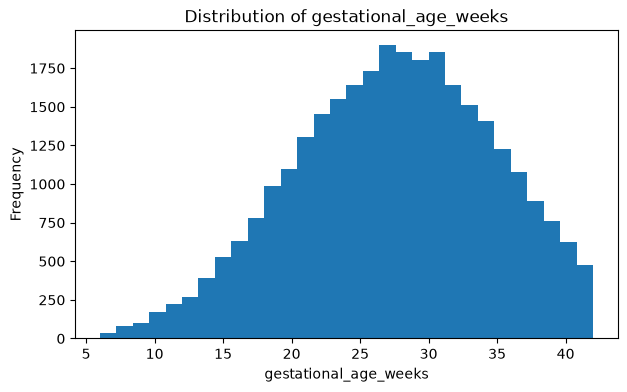

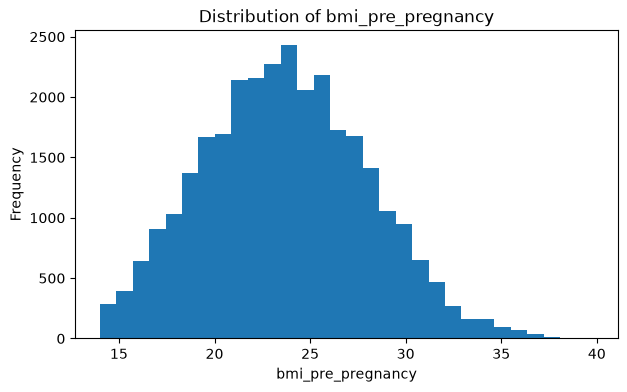

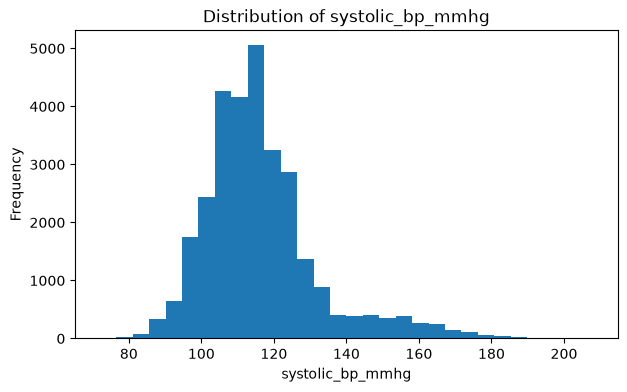

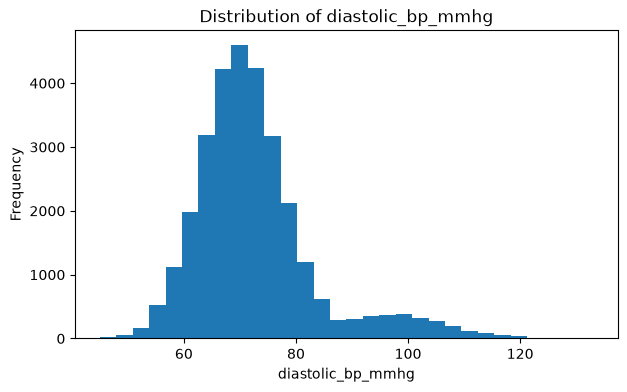

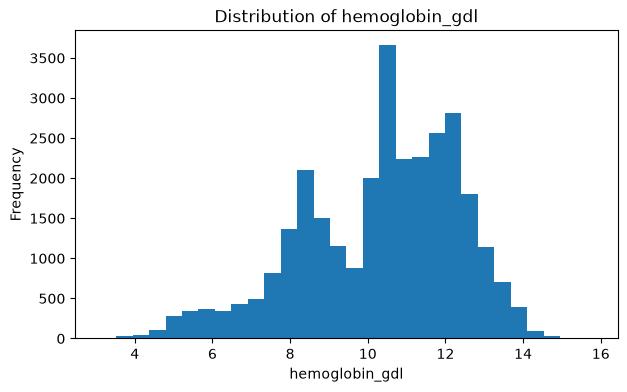

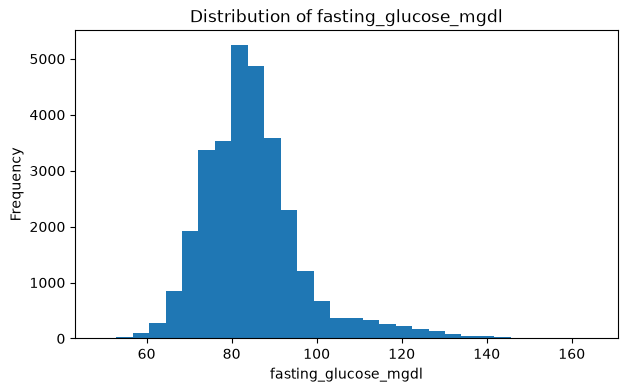

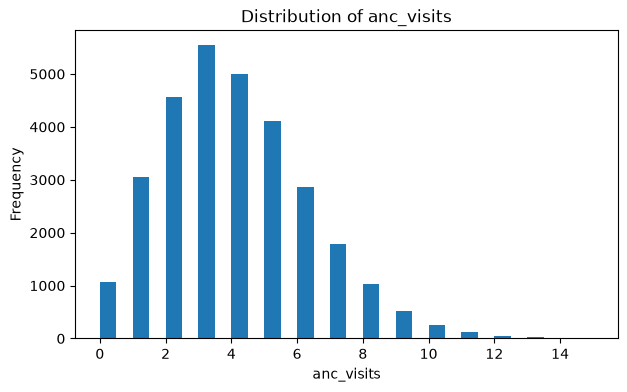

In [17]:
numerical_columns = [
    "age_years",
    "gravidity",
    "parity",
    "gestational_age_weeks",
    "bmi_pre_pregnancy",
    "systolic_bp_mmhg",
    "diastolic_bp_mmhg",
    "hemoglobin_gdl",
    "fasting_glucose_mgdl",
    "anc_visits"
]


for column in numerical_columns:

    values = df[column].drop_nulls().to_list()

    plt.figure(figsize=(7,4))

    plt.hist(
        values,
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

## Observation

- Distribution plots help identify:
    - Skewness
    - Normality
    - Extreme values

- Some medical measurements may naturally have wider variation among patients.

In [18]:
categorical_columns = [
    "anemia_status",
    "proteinuria",
    "hiv_status",
    "delivery_mode",
    "primary_complication",
    "pregnancy_outcome"
]


for column in categorical_columns:

    category_count = (
        df
        .group_by(column)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
    )

    print(f"\n{column}")
    print(category_count)



anemia_status
shape: (4, 2)
┌───────────────┬───────┐
│ anemia_status ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ none          ┆ 12903 │
│ moderate      ┆ 8653  │
│ mild          ┆ 6497  │
│ severe        ┆ 1947  │
└───────────────┴───────┘

proteinuria
shape: (5, 2)
┌─────────────┬───────┐
│ proteinuria ┆ count │
│ ---         ┆ ---   │
│ i64         ┆ u32   │
╞═════════════╪═══════╡
│ 0           ┆ 23324 │
│ 1           ┆ 3995  │
│ 3           ┆ 1044  │
│ 4           ┆ 917   │
│ 2           ┆ 720   │
└─────────────┴───────┘

hiv_status
shape: (2, 2)
┌────────────┬───────┐
│ hiv_status ┆ count │
│ ---        ┆ ---   │
│ i64        ┆ u32   │
╞════════════╪═══════╡
│ 0          ┆ 26971 │
│ 1          ┆ 3029  │
└────────────┴───────┘

delivery_mode
shape: (2, 2)
┌───────────────┬───────┐
│ delivery_mode ┆ count │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ vaginal       ┆ 26022 │
│ caesarean     ┆ 3978  │

In [29]:
## Correlation Analysis 
correlation_matrix = (
    df
    .select(numerical_columns)
    .corr()
)

correlation_matrix

age_years,gravidity,parity,gestational_age_weeks,bmi_pre_pregnancy,systolic_bp_mmhg,diastolic_bp_mmhg,hemoglobin_gdl,fasting_glucose_mgdl,anc_visits
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.661216,0.650579,0.001352,-0.004784,0.077448,0.051403,0.017623,0.024312,0.004128
0.661216,1.0,0.990602,0.004,0.002035,0.04149,0.022699,0.01278,0.018476,0.002782
0.650579,0.990602,1.0,0.002561,0.002876,0.042446,0.023967,0.011952,0.018582,0.001397
0.001352,0.004,0.002561,1.0,0.012334,-0.002552,0.002025,0.011829,-0.008231,0.404701
-0.004784,0.002035,0.002876,0.012334,1.0,0.142464,0.078487,0.000827,0.20927,0.004097
0.077448,0.04149,0.042446,-0.002552,0.142464,1.0,0.593338,0.035152,-0.01567,0.006841
0.051403,0.022699,0.023967,0.002025,0.078487,0.593338,1.0,0.040229,-0.03105,0.002695
0.017623,0.01278,0.011952,0.011829,0.000827,0.035152,0.040229,1.0,0.035599,-0.006287
0.024312,0.018476,0.018582,-0.008231,0.20927,-0.01567,-0.03105,0.035599,1.0,-0.010757


# Observation
The dataset does not show broad interdependence across variables. Instead, it shows a few expected clustered relationships: reproductive history variables move together, blood pressure measures move together, and longer pregnancies tend to involve more ANC (antenatal care) visits.

So, in summary, the outcome is a mostly weak-correlation dataset with a few clear, clinically plausible associations.
Correlation does not imply causation.

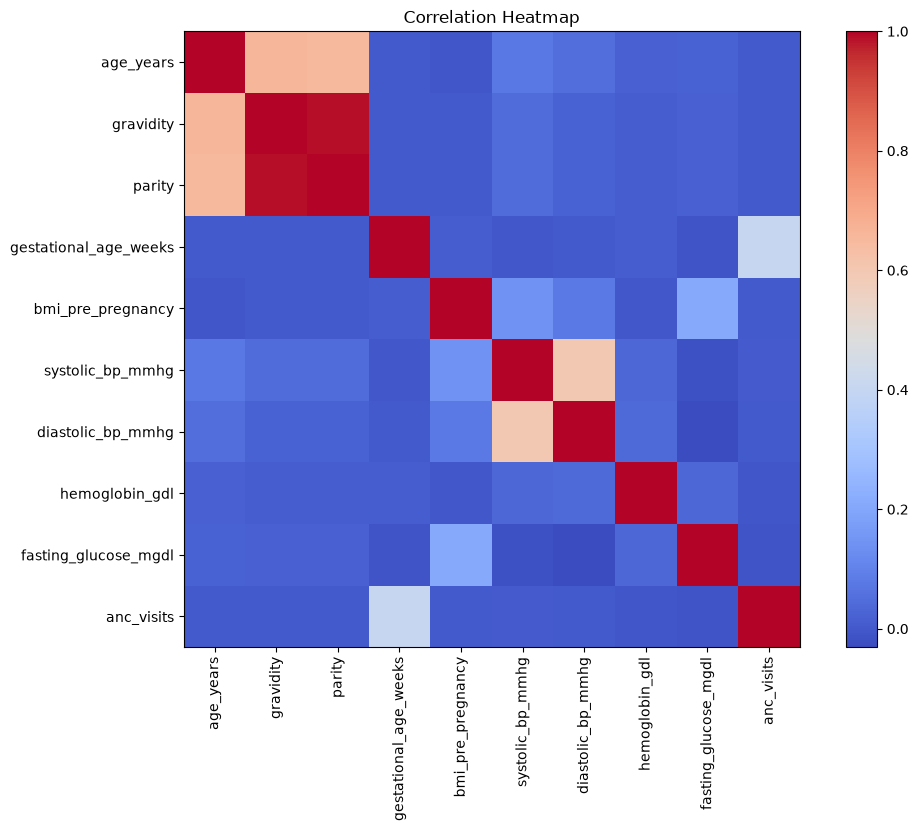

In [20]:
plt.figure(figsize=(12,8))

plt.imshow(
    correlation_matrix.to_numpy(),
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(numerical_columns)),
    numerical_columns,
    rotation=90
)

plt.yticks(
    range(len(numerical_columns)),
    numerical_columns
)

plt.title("Correlation Heatmap")

plt.show()

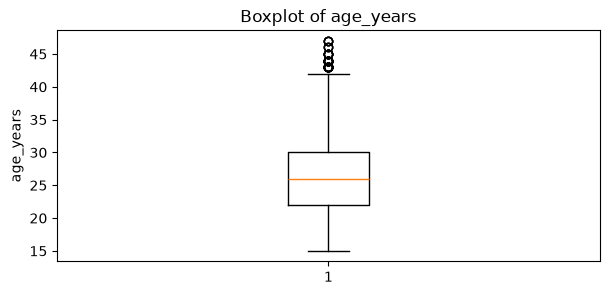

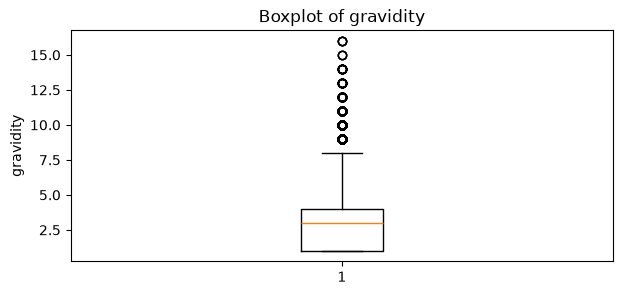

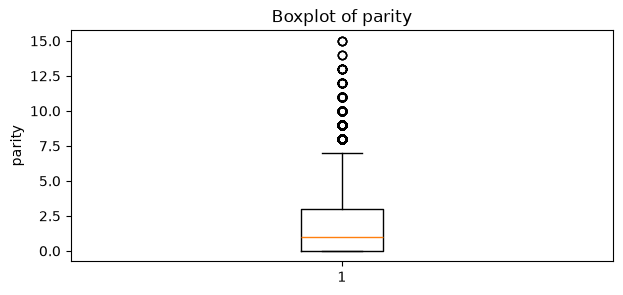

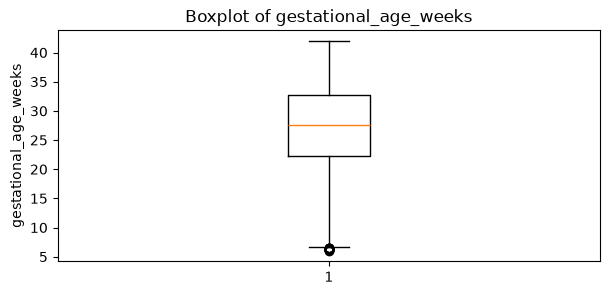

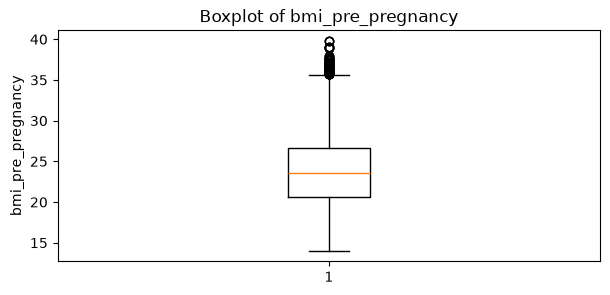

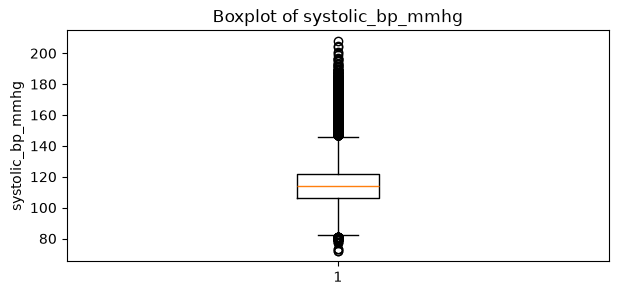

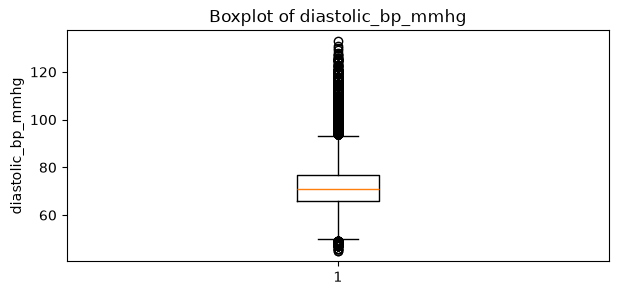

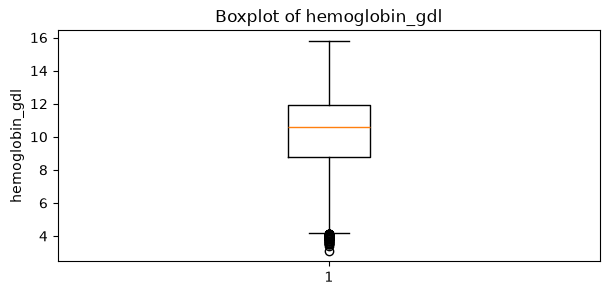

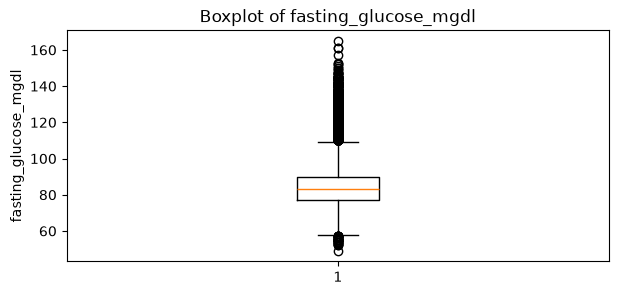

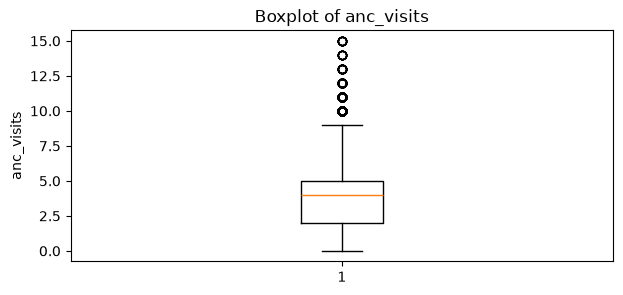

In [28]:
## Outlier detection
for column in numerical_columns:

    values = df[column].drop_nulls().to_list()

    plt.figure(figsize=(7,3))

    plt.boxplot(values)

    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

    plt.show()

# observation

- Boxplots help identify extreme values.
- Outliers should be investigated before removing them because medical data may naturally contain extreme cases.

In [23]:
complication_risk = (
    df
    .group_by(
        [
            "primary_complication",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

primary_complication,risk_level,count
str,str,u32
"""none""","""low""",12100
"""none""","""moderate""",6570
"""gestational_diabetes""","""moderate""",2635
"""none""","""high""",2439
"""severe_anemia""","""high""",1861
"""preeclampsia""","""moderate""",1356
"""hemorrhage""","""high""",1251
"""preeclampsia""","""high""",982
"""gestational_diabetes""","""high""",463


In [30]:
complication_risk = (
    df
    .group_by(
        [
            "age_years",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

age_years,risk_level,count
i64,str,u32
25,"""low""",999
26,"""low""",956
27,"""low""",940
24,"""low""",930
28,"""low""",852
…,…,…
44,"""high""",25
40,"""high""",19
45,"""high""",7


In [31]:
complication_risk = (
    df
    .group_by(
        [
            "hiv_status",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

hiv_status,risk_level,count
i64,str,u32
0,"""low""",12100
0,"""moderate""",10561
0,"""high""",4310
1,"""high""",3029


In [32]:
complication_risk = (
    df
    .group_by(
        [
            "anemia_status",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

anemia_status,risk_level,count
str,str,u32
"""none""","""low""",8056
"""moderate""","""moderate""",6132
"""mild""","""low""",4044
"""none""","""moderate""",2978
"""moderate""","""high""",2521
"""severe""","""high""",1947
"""none""","""high""",1869
"""mild""","""moderate""",1451
"""mild""","""high""",1002


In [33]:
complication_risk = (
    df
    .group_by(
        [
            "delivery_mode",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

delivery_mode,risk_level,count
str,str,u32
"""vaginal""","""low""",10565
"""vaginal""","""moderate""",9131
"""vaginal""","""high""",6326
"""caesarean""","""low""",1535
"""caesarean""","""moderate""",1430
"""caesarean""","""high""",1013


In [34]:
complication_risk = (
    df
    .group_by(
        [
            "pregnancy_outcome",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

pregnancy_outcome,risk_level,count
str,str,u32
"""live_birth""","""low""",12100
"""live_birth""","""moderate""",10561
"""live_birth""","""high""",7009
"""stillbirth""","""high""",288
"""maternal_death""","""high""",42


In [35]:
complication_risk = (
    df
    .group_by(
        [
            "systolic_bp_mmhg",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

systolic_bp_mmhg,risk_level,count
i64,str,u32
111,"""low""",502
113,"""low""",469
110,"""low""",468
114,"""low""",463
112,"""low""",460
…,…,…
72,"""moderate""",1
197,"""high""",1
199,"""high""",1


In [36]:
complication_risk = (
    df
    .group_by(
        [
            "hemoglobin_gdl",
            "risk_level"
        ]
    )
    .agg(
        pl.len()
        .alias("count")
    )
    .sort("count", descending=True)
)

complication_risk

hemoglobin_gdl,risk_level,count
f64,str,u32
10.5,"""low""",519
10.4,"""low""",513
10.6,"""low""",436
11.7,"""low""",431
10.3,"""low""",424
…,…,…
3.1,"""high""",1
15.0,"""moderate""",1
14.7,"""high""",1


# Key Findings from EDA

## Data Quality

- Dataset structure was reviewed.
- Missing values and duplicate records were checked.
- Data types were verified.

## Feature Insights

- Maternal demographic factors, pregnancy history, clinical measurements, and health conditions were explored.
- Blood pressure, haemoglobin level, glucose level, and pregnancy complications may provide important signals for risk prediction.

## Target Variable

- The distribution of maternal risk categories was examined.
- Class balance should be considered during model evaluation.

## Next Steps

The next stage of the project will involve:

1. Data preprocessing
2. Feature encoding
3. Feature selection
4. Model development
5. Model evaluation